# chemsar quickstart: end-to-end QSAR pipeline

This notebook walks through the full workflow: preparing molecules, computing
descriptors, building a dataset, preprocessing it, and training/evaluating a
model.

**About the data:** the molecules below are real, simple, well-known
compounds (aspirin, caffeine, ibuprofen, etc.), but the "activity" (`IC50`)
values are **synthetically generated** for this notebook -- a made-up
function of molecular weight and polar surface area, plus noise -- purely so
the pipeline has something meaningful to learn from. They are *not* real
experimental measurements.

All outputs this notebook writes (prepared structures, descriptor tables,
diagnostic CSVs) go into `examples/output/`, which is git-ignored.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

from chemsar import mol_enumerate, desc, dataframe, data_prep, Model

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)
os.chdir(OUTPUT_DIR)  # chemsar's preprocessing/modeling functions write several
                      # diagnostic CSVs to the current working directory
np.random.seed(0)

Failed to patch pandas - PandasTools will have limited functionality


## 1. Example molecules

A small, diverse set of well-known small molecules, written out as a
SMILES file (the format `mol_enumerate` expects for `input_format="smi"`).

In [2]:
molecules = {
    "aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "caffeine": "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
    "ibuprofen": "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "paracetamol": "CC(=O)Nc1ccc(O)cc1",
    "ethanol": "CCO",
    "benzene": "c1ccccc1",
    "toluene": "Cc1ccccc1",
    "phenol": "Oc1ccccc1",
    "acetone": "CC(=O)C",
    "acetic_acid": "CC(=O)O",
    "naphthalene": "c1ccc2ccccc2c1",
    "pyridine": "c1ccncc1",
    "furan": "c1ccoc1",
    "thiophene": "c1ccsc1",
    "imidazole": "c1cnc[nH]1",
    "indole": "c1ccc2[nH]ccc2c1",
    "quinoline": "c1ccc2ncccc2c1",
    "cyclohexane": "C1CCCCC1",
    "methanol": "CO",
    "propanol": "CCCO",
    "butanol": "CCCCO",
    "chlorobenzene": "Clc1ccccc1",
    "bromobenzene": "Brc1ccccc1",
    "nitrobenzene": "O=[N+]([O-])c1ccccc1",
    "aniline": "Nc1ccccc1",
    "benzaldehyde": "O=Cc1ccccc1",
    "benzoic_acid": "O=C(O)c1ccccc1",
    "styrene": "C=Cc1ccccc1",
    "anisole": "COc1ccccc1",
    "salicylic_acid": "O=C(O)c1ccccc1O",
}

smi_df = pd.DataFrame(
    {"smiles": molecules.values(), "name": molecules.keys()}
)
smi_df.to_csv("molecules.smi", index=False)
smi_df

,smiles,name
0,CC(=O)Oc1ccccc1C(=O)O,aspirin
1,Cn1cnc2c1c(=O)n(C)c(=O)n2C,caffeine
2,CC(C)Cc1ccc(cc1)C(C)C(=O)O,ibuprofen
3,CC(=O)Nc1ccc(O)cc1,paracetamol
4,CCO,ethanol
5,c1ccccc1,benzene
6,Cc1ccccc1,toluene
7,Oc1ccccc1,phenol
8,CC(=O)C,acetone
9,CC(=O)O,acetic_acid


## 2. Prepare molecules

`mol_enumerate` strips salts, embeds a 3D conformer, and computes Gasteiger
charges for each molecule, writing both a 3D and a 2D SDF.

In [3]:
prepared = mol_enumerate(
    "molecules.smi",
    "prepared_3d.sdf",
    "prepared_2d.sdf",
    input_format="smi",
)
print(f"prepared {len(prepared)} of {len(molecules)} molecules")

len(input_molecules) 30
0 aspirin to 3d
skipping molecule 9: failed to prepare molecule 'acetic_acid': molecule has no atoms


prepared 29 of 30 molecules


You'll see `acetic_acid` get skipped with a warning rather than silently
dropped or replaced: RDKit's default `SaltRemover` treats acetic acid itself
as a salt/counter-ion, so stripping it leaves zero atoms. `mol_enumerate`
raises a clear error for molecules like this and skips them, rather than
(as an earlier version of this pipeline did) silently substituting a fake
placeholder molecule and continuing.

## 3. Generate descriptors and a synthetic activity

`desc()` computes RDKit descriptors for every prepared molecule; we use the
"interpretable" subset (counts, fragment counts, molecular weight, TPSA --
easy to reason about for a demo). Then we simulate an activity value and
merge it in with `dataframe()`, matching by molecule name.

In [4]:
desc_result = desc("prepared_3d.sdf", source="sdf", selected_des="interpretable")
names, descriptor_names, values = desc_result
print(f"{len(descriptor_names)} descriptors computed for {len(names)} molecules")

desc_df = pd.DataFrame(values, index=names, columns=descriptor_names)

# Synthetic activity: a made-up function of MolWt/TPSA plus noise, purely to
# give the model a learnable (but fake) signal.
synthetic_ic50 = (
    -0.05 * desc_df["MolWt"]
    - 0.1 * desc_df["TPSA"]
    + np.random.normal(scale=2.0, size=len(desc_df))
)
activities = pd.DataFrame({"name": names, "IC50": synthetic_ic50.values})
activities.to_csv("activities.csv", index=False)

merged = dataframe(desc_result, "activities.csv", "merged.csv", target="IC50")
merged.head()

110 descriptors computed for 29 molecules


,name,IC50,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,TPSA,NumAliphaticCarbocycles,NumAliphaticHeterocycles,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,aspirin,-11.839845,180.159,172.095,180.042259,68,0,63.60,0,0,...,0,0,0,0,0,0,0,0,0,0
1,caffeine,-15.091386,194.194,184.114,194.080376,74,0,61.82,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ibuprofen,-12.086774,206.285,188.141,206.130680,82,0,37.30,0,0,...,0,0,0,0,0,0,0,0,0,0
3,paracetamol,-8.009464,151.165,142.093,151.063329,58,0,49.33,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ethanol,-0.591334,46.069,40.021,46.041865,20,0,20.23,0,0,...,0,0,0,0,0,0,0,0,0,0


## 4. Preprocess the dataset

`data_prep` handles scaling, correlation filtering, feature selection, and
the train/test split in one call. It also writes an applicability-domain
(CI) report -- see `CI_train.csv` / `CI_test.csv` in `examples/output/`.

In [5]:
result = data_prep(
    "merged.csv",
    Scaled="on",
    Cor="on",
    FS="reg",
    ndes=6,
    mod="reg",
    ratio=0.25,
    rs=0,
)
X_train, y_train, X_test, y_test, v_names = result[:5]
print("selected features:", v_names)
print("train/test sizes:", X_train.shape, X_test.shape)

selected features: ['HeavyAtomMolWt', 'NumHAcceptors', 'NumRotatableBonds', 'fr_Ar_COO', 'fr_COO2', 'fr_NH0']
train/test sizes: (21, 6) (8, 6)


## 5. Train and evaluate a model

A random forest regressor, evaluated on the training fit, leave-one-out
cross-validation, and the held-out test set.

In [6]:
model_result, cv_metrics, fitted_model, analysis = Model(
    X_train, y_train, X_test, y_test, v_names, M="rf", c=3, rs=0, cv="loo"
)

print("Train R^2:      %.3f" % model_result["R2"])
print("Test R^2:       %.3f" % model_result["R2_test"])
print("CV Q^2 (LOO):   %.3f" % cv_metrics["q2"])
print("CV RMSE (LOO):  %.3f" % cv_metrics["RMSECV"])
model_result["Variable Importance"]

Train R^2:      0.690
Test R^2:       0.225
CV Q^2 (LOO):   0.487
CV RMSE (LOO):  2.429


,0
NumRotatableBonds,0.009613
fr_COO2,0.013906
fr_NH0,0.029676
fr_Ar_COO,0.266647
HeavyAtomMolWt,0.323720
NumHAcceptors,0.356437


## 6. Predicted vs. observed

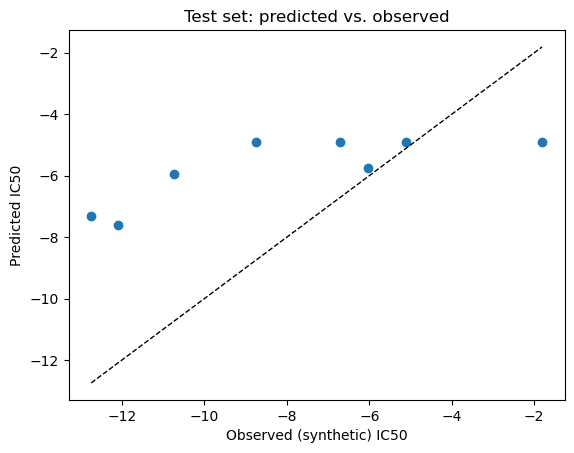

In [7]:
import matplotlib.pyplot as plt

y_pred_test = fitted_model.predict(X_test)

plt.scatter(y_test, y_pred_test)
lims = [min(*y_test, *y_pred_test), max(*y_test, *y_pred_test)]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("Observed (synthetic) IC50")
plt.ylabel("Predicted IC50")
plt.title("Test set: predicted vs. observed")
plt.show()

## Next steps

- Swap in a real SDF/SMILES file and real activity data.
- Try other model types: `Model(..., M="pls")`, `M="svm"`, `M="nn"`, etc.
- For classification tasks, see `ModelC` instead of `Model`.
- See the module table in the repo's `README.md` for what else is available
  (fingerprints, LIME-based interpretability, clustering, ...).